# Nested classification
- Extend of 01_flat_classifier
- NOTE:
  - We also do multi-label output in this case
  - vs Categorial, it is single label, so for output, we replace activation from **SoftMax** to **Sigmoid**
  
```python
  # OUTPUT LAYER — change activation
# Before (single-label):
tf.keras.layers.Dense(num_classes, activation='softmax')

# After (multi-label):
tf.keras.layers.Dense(num_classes, activation='sigmoid')
```

* for the compile
```python
# COMPILE — change loss
# Before:
model.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# After:
model.compile(optimizer='adam',
            loss='binary_crossentropy',   # evaluates each label independently
            metrics=['accuracy'])
```
* for the labels
```python
# LABELS — must be one-hot encoded, not integer
# Before (single-label integer):
y = [2, 0, 4, 1, ...]

# After (multi-label binary vector):
y = [[0,0,1,0,0,0],   # label 2
     [1,0,0,0,1,0],   # labels 0 AND 4
     ...]
```  
* Prediction:
```python
# PREDICTION — threshold instead of argmax
# Before:
predicted_class = np.argmax(model.predict(x))

# After:
probs = model.predict(x)           # shape: (1, num_classes)
predicted_labels = (probs > 0.5)   # True/False per class
```

In [1]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from datasets import load_dataset_builder
import numpy as np

c:\Users\anhmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "google-research-datasets/go_emotions"
dataset = load_dataset_builder(DATASET_NAME)

In [3]:
print(dataset.name)
print(dataset.info.features.keys())
print(dataset.info.features["text"])
print(dataset.info.features["labels"])

parquet
dict_keys(['text', 'labels', 'id'])
Value('string')
List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']))


In [4]:
dataset = load_dataset(DATASET_NAME)

In [5]:
print(dataset)
print("---" * 10)
LABELS = dataset["train"].features["labels"].feature.names
print("total number of labels: ", len(LABELS))
print(LABELS)
print("---" * 10)
# output first 5 train sentences and their labels
for i in range(5, 10):
    print(f"Sentence: {dataset['train'][i]['text']}")
    print(f"Labels: {dataset['train'][i]['labels']}: {[LABELS[dataset['train'][i]['labels'][j]] for j in range(len(dataset['train'][i]['labels']))]}")


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
------------------------------
total number of labels:  28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
------------------------------
Sentence: OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.
Labels: [26]: ['surprise']
Sentence: Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝
Label

### Set the coarse labels from the 01_flat_classifier
- phase 1 have 6 labels, being: anger, sadness, joy, love, fear, suprise
- use this to categorize the table of emotion first to visualize
NOTE:
- WE DO NOT NEED NEUTRAL CATEGORY !!!!!
- Since we are using sigmoid and threshold to determine multi-lables, if all labels below threshold -> neutral

In [6]:
coarse_labels = set("anger,joy,sadness,fear,love,surprise".split(","))
print(coarse_labels)
coarse_to_fine_labels = {coarse_label: [] for coarse_label in coarse_labels}
for coarse_label in coarse_labels:
    match coarse_label:
        case "anger":
            coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "anger, annoyance, disapproval, disgust".split(",")]
        case "joy":
            coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "joy, amusement, excitement, optimism, gratitude, pride, relief,approval".split(",")]
        case "sadness":
            coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "sadness, grief, remorse, disappointment, embarrassment".split(",")]
        case "fear":
            coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "fear, nervousness".split(",")]
        case "love":
            coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "love, admiration, caring, desire".split(",")]
        case "surprise":
            coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "surprise, curiosity, realization, confusion".split(",")]
        # case "neutral":
        #     coarse_to_fine_labels[coarse_label] = [entry.strip() for entry in "neutral".split(",")]
        case _:
            raise ValueError(f"Unknown coarse label: {coarse_label}")
print(coarse_to_fine_labels)
HIERARCHY = coarse_to_fine_labels
COARSE_CLASSES = list(HIERARCHY.keys())
FINE_CLASSES   = [f for subs in HIERARCHY.values() for f in subs]

COARSE_TO_FINE = HIERARCHY
FINE_TO_COARSE = {fine: coarse
    for coarse, fines in HIERARCHY.items() for fine in fines}
COARSE_IDX = {c: i for i, c in enumerate(COARSE_CLASSES)}
FINE_IDX   = {f: i for i, f in enumerate(FINE_CLASSES)}

print(len(LABELS), len(FINE_CLASSES))
# verify we have enough
print(set(LABELS) - set(FINE_CLASSES) - {'neutral'})

{'anger', 'love', 'sadness', 'surprise', 'joy', 'fear'}
{'anger': ['anger', 'annoyance', 'disapproval', 'disgust'], 'love': ['love', 'admiration', 'caring', 'desire'], 'sadness': ['sadness', 'grief', 'remorse', 'disappointment', 'embarrassment'], 'surprise': ['surprise', 'curiosity', 'realization', 'confusion'], 'joy': ['joy', 'amusement', 'excitement', 'optimism', 'gratitude', 'pride', 'relief', 'approval'], 'fear': ['fear', 'nervousness']}
28 27
set()


## Explore data

In [7]:
from collections import Counter

import pandas as pd

# flatten the labels from train set, or basically flatten the Y_train
flatten_labels = [
    LABELS[label_name]
    for labels in dataset["train"]["labels"]
    for label_name in labels
]
print("first 10 flattened labels: ")
print(flatten_labels[:10])
print("---" * 10)

# into a dataframe and count the number of occurrences of each label
df = pd.DataFrame(Counter(flatten_labels).items(), columns=["label", "COUNT"])
df['pct'] = (df['COUNT'] / df['COUNT'].sum() * 100).round(2)
df = df.sort_values("COUNT", ascending=False)
print(df.head(10))



first 10 flattened labels: 
['neutral', 'neutral', 'anger', 'fear', 'annoyance', 'surprise', 'gratitude', 'desire', 'optimism', 'admiration']
------------------------------
          label  COUNT    pct
0       neutral  14219  27.82
8    admiration   4130   8.08
11     approval   2939   5.75
5     gratitude   2662   5.21
3     annoyance   2470   4.83
10    amusement   2328   4.56
18    curiosity   2191   4.29
20         love   2086   4.08
22  disapproval   2022   3.96
7      optimism   1581   3.09


# Visualize
- Note: we already remove neutral column, it takes nearly 38% of data , but should not consider it

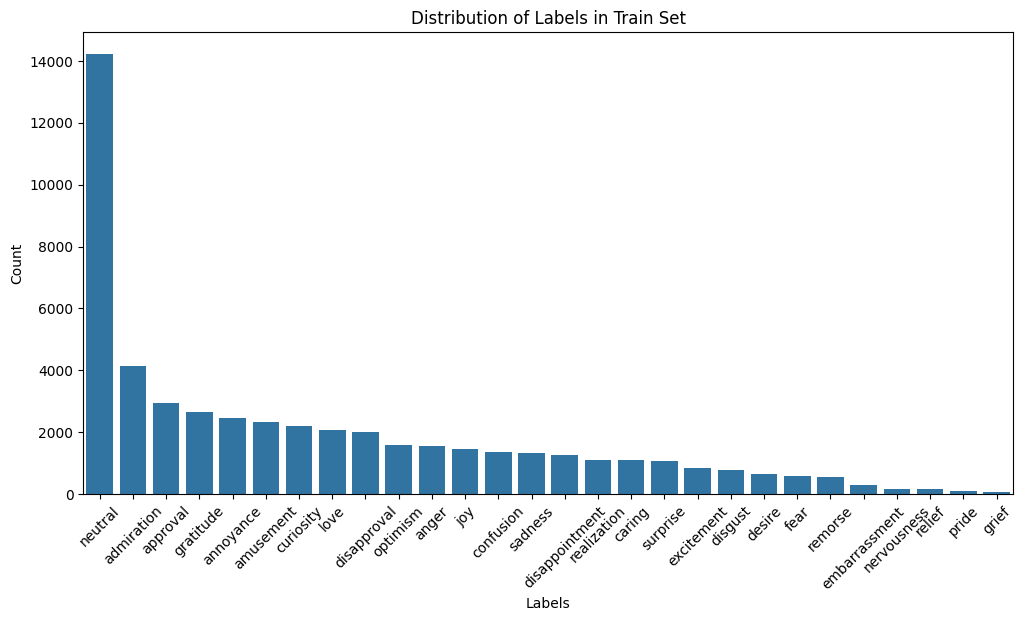

In [8]:
# visualize the distribution of labels in the train set
plt.figure(figsize=(12, 6))
sns.barplot(x="label", y="COUNT", data=df.sort_values("COUNT", ascending=False))
plt.xticks(rotation=45)
plt.title("Distribution of Labels in Train Set")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

# Conclude from Data + what to do
- Neutral can remove, but the bot and top distirbution is still not fit, the ratio is too large (150x)
- use over + under sampling to add random sample to bot emotion and remove some from top emotion (to balance things out for ```class_weight``` when doing ```gradient_descent``` it will be more stabelized + less oscillates)

# Filter neutral
- We don't need neutral classification (claude said so, i don't know)

In [9]:
# Find the neutral label ID
neutral_id = LABELS.index('neutral')

# Filter out samples where the only label is neutral
def is_not_neutral(sample):
    return not (len(sample['labels']) == 1 and sample['labels'][0] == neutral_id)

print("before_filtering: ", len(dataset['train']))
dataset_cleaned = dataset.map(lambda x: x).filter(is_not_neutral)
print("after_filtering: ", len(dataset_cleaned['train']))
# dataset = dataset_cleaned

before_filtering:  43410
after_filtering:  30587


# Cap dominant classes
- run some stuff to solve over/under sampling
- do some cap classes

In [10]:
flat = [LABELS[l]
        for sample in dataset_cleaned['train']
        for l in sample['labels']]

df_cleaned = pd.DataFrame(Counter(flat).items(), columns=["emotion", "COUNT"])
df_cleaned = df_cleaned.sort_values("COUNT", ascending=False)
print(df_cleaned.head(10).to_string())

        emotion  COUNT
7    admiration   4130
10     approval   2939
4     gratitude   2662
2     annoyance   2470
9     amusement   2328
18    curiosity   2191
20         love   2086
22  disapproval   2022
6      optimism   1581
0         anger   1567


In [11]:
import random
from typing import Counter
random.seed(42)

train_dataset = dataset_cleaned["train"]

CAP = 2000 # pick a cap to undersample dominant class

def cap_dataset(split,cap):
    # Group sample indices by their dominant label
    label_indices = Counter()
    kept = []

    for sample in split:
        # count dominant label (first label in list)
        dominant = FINE_CLASSES[sample['labels'][0]]
        label_indices[dominant] += 1

        # only keep if we haven't hit the cap for this label yet
        if label_indices[dominant] <= cap:
            kept.append(sample)

    return kept

train_capped = cap_dataset(train_dataset, CAP)
print(f"Train before cap: {len(train_dataset)}")
print(f"Train after cap:  {len(train_capped)}")

Train before cap: 30587
Train after cap:  27383


# Label Preprocessing — Two Binary Vectors
This is the most different part from Phase 1. Instead of one integer label per sample, we produce two binary vectors per sample.


In [12]:
NUM_COARSE = len(COARSE_CLASSES)
NUM_FINE = len(FINE_CLASSES)
print(NUM_COARSE, NUM_FINE)
print(FINE_CLASSES)
# lid = label_id ( in go dataset it is an integer)
# ── Encode one sample ────────────────────────────────────────────────────
def encode_labels(sample_labels):
    y_coarse = np.zeros(NUM_COARSE, dtype=np.float32)
    y_fine   = np.zeros(NUM_FINE,   dtype=np.float32)
    for lid in sample_labels:
        fine_name = LABELS[lid]
        if fine_name not in FINE_TO_COARSE:
            continue
        y_coarse[COARSE_IDX[FINE_TO_COARSE[fine_name]]] = 1.0
        y_fine[FINE_IDX[fine_name]]                     = 1.0
    return y_coarse, y_fine
# ── Encode full split ────────────────────────────────────────────────────
def encode_split(samples):
    texts, yc_all, yf_all = [], [], []
    for s in samples:
        yc, yf = encode_labels(s['labels'])
        if yf.sum() == 0:
            continue
        texts.append(s['text'])
        yc_all.append(yc)
        yf_all.append(yf)
    return texts, np.array(yc_all), np.array(yf_all)

train_texts, y_coarse_train, y_fine_train = encode_split(train_capped)
val_texts,   y_coarse_val,   y_fine_val   = encode_split(dataset_cleaned['validation'])
test_texts,  y_coarse_test,  y_fine_test  = encode_split(dataset_cleaned['test'])

print(f"Train: {len(train_texts)} samples")
print(f"y_coarse shape: {y_coarse_train.shape}")  # (N, 6)
print(f"y_fine shape:   {y_fine_train.shape}")    # (N, 27)

6 27
['anger', 'annoyance', 'disapproval', 'disgust', 'love', 'admiration', 'caring', 'desire', 'sadness', 'grief', 'remorse', 'disappointment', 'embarrassment', 'surprise', 'curiosity', 'realization', 'confusion', 'joy', 'amusement', 'excitement', 'optimism', 'gratitude', 'pride', 'relief', 'approval', 'fear', 'nervousness']
Train: 27383 samples
y_coarse shape: (27383, 6)
y_fine shape:   (27383, 27)


# Tokenization
- Identical to phase 1

In [13]:
from keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

Tokenizer = tf.keras.preprocessing.text.Tokenizer

VOCAB_SIZE = 15000
MAX_LEN = 50
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<NONCE>")
tokenizer.fit_on_texts(train_texts)

x_train = pad_sequences(padding="post",maxlen= MAX_LEN, sequences=tokenizer.texts_to_sequences(train_texts), truncating="post")
x_val = pad_sequences(padding="post",maxlen= MAX_LEN, sequences=tokenizer.texts_to_sequences(val_texts), truncating="post")
x_test = pad_sequences(padding="post",maxlen= MAX_LEN, sequences=tokenizer.texts_to_sequences(test_texts), truncating="post")

print(f"X_train: {x_train.shape}")   # (27383, 50)
print(f"X_val:   {x_val.shape}")
print(f"X_test:  {x_test.shape}")


X_train: (27383, 50)
X_val:   (3834, 50)
X_test:  (3821, 50)


In [ ]:
from keras import layers, Model, Input
# we gonna transform a sentence to a token sequence => max len after pad
# ── Input ────────────────────────────────────────────────────────
input_layer = Input(shape=(MAX_LEN,))
  # ── Shared Encoder (same as Phase 1) ────────────────────────────
x = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN, name="embedding")(input_layer)
x = layers.Bidirectional(layers.LSTM(64), name='bilstm')(x)
x = layers.Dropout(0.3, name="dropout1")(x)
x = layers.Dense(128, activation="relu", name="dense1")(x) # the unit was 64, but after test, 128 significantly improve the metric !!! 
x = layers.Dropout(0.3, name="dropout2")(x)
# ── Two Output Heads ────────────────────────────────────────────
coarse_out = layers.Dense(NUM_COARSE, activation="sigmoid", name="coarse_out")(x)
fine_out   = layers.Dense(NUM_FINE,   activation="sigmoid", name="fine_out")(x)

model = Model(inputs=input_layer, outputs=[coarse_out, fine_out], name="nested_emotion_classifier")
model.summary()


c:\Users\anhmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "nested_emotion_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    960,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128)       │     66,048 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 128)       │          0 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 128)       │     16,512 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 128)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coarse_out (Dense)  │ (None, 6)         │        774 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fine_out (Dense)    │ (None, 27)        │      3,483 │ dropout2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,046,817 (3.99 MB)

 Trainable params: 1,046,817 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

# Model breakdown
dropout2  →  coarse_out (6 units) <br>
dropout2  →  fine_out   (27 units) <br>

Both heads connect to the same dropout2 layer — that's your shared encoder splitting into two branches. Exactly what we designed.<br>
Parameter breakdown: <br>

embedding: 960,000 — biggest chunk, expected (15000 vocab × 64 dims) <br>
bilstm: 66,048 — BiLSTM is expensive but shared between both tasks <br>
coarse_out: 390 — tiny (64 × 6 + 6 bias) <br>
fine_out: 1,755 — also small (64 × 27 + 27 bias) <br>

# Loss weight
- total_loss = loss_coarse + loss_fine
- But those two losses are on very different scales — loss_coarse is over 6 classes, loss_fine is over 27. 
- => If just add them raw, the optimizer doesn't know which one to prioritize.
- => loss_weights turns it into: <br>
```
total_loss = 0.3 * loss_coarse + 0.7 * loss_fine
```
- just a weighted sum. The weights control how much each head's error contributes to the total gradient signal.
So if loss_coarse = 0.8 and loss_fine = 1.2: <br>
total_loss = 0.3 * 0.8  +  0.7 * 1.2 <br>
           = 0.24       +  0.84 <br>
           = 1.08 <br>

In [21]:
model.compile(
    optimizer="adam",
    loss={
        "coarse_out": "binary_crossentropy",
        "fine_out": "binary_crossentropy"
        },
    metrics={
        "coarse_out": ["accuracy"],
        "fine_out": ["accuracy"]
        },
    loss_weights={
        "coarse_out": 0.3,
        "fine_out": 0.7
    }
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model_phase2.keras', monitor='val_loss', save_best_only=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

# Fit the model

In [22]:
history = model.fit(
    x = x_train,
    y = {
            "coarse_out": y_coarse_train,
            "fine_out": y_fine_train
        },
    validation_data=(
        x_val, 
        {
            "coarse_out": y_coarse_val,
            "fine_out": y_fine_val
        }
    ),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - coarse_out_accuracy: 0.2716 - coarse_out_loss: 0.4715 - fine_out_accuracy: 0.0650 - fine_out_loss: 0.2126 - loss: 0.2903 - val_coarse_out_accuracy: 0.3732 - val_coarse_out_loss: 0.4109 - val_fine_out_accuracy: 0.1299 - val_fine_out_loss: 0.1666 - val_loss: 0.2399 - learning_rate: 0.0010
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - coarse_out_accuracy: 0.4768 - coarse_out_loss: 0.3688 - fine_out_accuracy: 0.1785 - fine_out_loss: 0.1596 - loss: 0.2224 - val_coarse_out_accuracy: 0.5485 - val_coarse_out_loss: 0.3276 - val_fine_out_accuracy: 0.2371 - val_fine_out_loss: 0.1445 - val_loss: 0.1994 - learning_rate: 0.0010
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - coarse_out_accuracy: 0.6223 - coarse_out_loss: 0.2972 - fine_out_accuracy: 0.2753 - fine_out_loss: 0.1416 - loss: 0.1883 - val_coarse_out_accuracy: 0.6215 - val_coarse_out_loss: 0.2975 - val_fine_out_accuracy: 0.3307 - val_fine_out_loss: 0.1329 - val_loss:

# Evaluate model
- For multi-label classification the standard metrics are:
1. Macro F1 — average F1 per label, treats all labels equally. This is your primary metric. A rare label counts the same as a common one.
2. Micro F1 — pools all predictions together. Dominated by frequent labels — useful but can hide poor performance on rare classes.
3. Hamming Loss — fraction of individual label predictions that are wrong. 0 = perfect.

In [23]:


# get raw predictions
coarse_raw, fine_raw = model.predict(x_test)
print("first 3 coarse raw predictions: ", coarse_raw[:3])
print("first 3 fine raw predictions: ", fine_raw[:3])

120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
first 3 coarse raw predictions:  [[0.01850324 0.53005236 0.670346   0.01579369 0.03148281 0.17217702]
 [0.9228492  0.05437129 0.05441259 0.01921788 0.04711292 0.03039959]
 [0.00691137 0.32004416 0.01118521 0.00869226 0.9323557  0.00285635]]
first 3 fine raw predictions:  [[0.00760829 0.01282738 0.0059785  0.00635314 0.17528749 0.01204833
  0.1022839  0.09196695 0.28429082 0.01635917 0.10404576 0.0569206
  0.01773999 0.00172074 0.0074395  0.00950925 0.00242675 0.00908393
  0.0021288  0.0026958  0.02713783 0.00097147 0.00214154 0.00197691
  0.00715715 0.11677244 0.03019558]
 [0.3852169  0.36672235 0.2025077  0.20458204 0.01845486 0.00700433
  0.02770635 0.00307662 0.02223316 0.0015616  0.0023999  0.04065569
  0.01052521 0.00366251 0.00982529 0.01494942 0.01126978 0.00215699
  0.00663217 0.00199059 0.00364496 0.00076605 0.00069163 0.00107522
  0.02749522 0.02977115 0.00339977]
 [0.00140488 0.00441789 0.00265646 0.00056943 0.02538916 0.13927975
  0

In [26]:
from sklearn.metrics import f1_score, hamming_loss, classification_report
# apply threshold
THRESHOLD = 0.15
coarse_pred = (coarse_raw >= THRESHOLD).astype(int)
fine_pred   = (fine_raw   >= THRESHOLD).astype(int)

# coarse metrics
print("=== COARSE (6 classes) ===")
print(f"Macro F1:    {f1_score(y_coarse_test, coarse_pred, average='macro',  zero_division=0):.4f}")
print(f"Micro F1:    {f1_score(y_coarse_test, coarse_pred, average='micro',  zero_division=0):.4f}")
print(f"Hamming:     {hamming_loss(y_coarse_test, coarse_pred):.4f}")

# fine metrics
print("\n=== FINE (27 classes) ===")
print(f"Macro F1:    {f1_score(y_fine_test, fine_pred, average='macro',  zero_division=0):.4f}")
print(f"Micro F1:    {f1_score(y_fine_test, fine_pred, average='micro',  zero_division=0):.4f}")
print(f"Hamming:     {hamming_loss(y_fine_test, fine_pred):.4f}")

# per label breakdown
print("\n=== FINE per-label report ===")
print(classification_report(y_fine_test, fine_pred,
                            target_names=FINE_CLASSES, zero_division=0))

=== COARSE (6 classes) ===
Macro F1:    0.5490
Micro F1:    0.6097
Hamming:     0.1903

=== FINE (27 classes) ===
Macro F1:    0.2530
Micro F1:    0.3714
Hamming:     0.0785

=== FINE per-label report ===
                precision    recall  f1-score   support

         anger       0.23      0.63      0.34       198
     annoyance       0.22      0.61      0.32       320
   disapproval       0.18      0.52      0.27       267
       disgust       0.24      0.45      0.32       123
          love       0.36      0.81      0.50       238
    admiration       0.43      0.66      0.52       504
        caring       0.15      0.12      0.13       135
        desire       0.46      0.07      0.12        83
       sadness       0.27      0.58      0.37       156
         grief       0.00      0.00      0.00         6
       remorse       0.26      0.77      0.38        56
disappointment       0.14      0.15      0.15       151
 embarrassment       0.00      0.00      0.00        37
      surp

In [20]:
print(f"Avg max fine probability: {fine_raw.max(axis=1).mean():.4f}")
print(f"Avg fine probabilities:   {fine_raw.mean():.4f}")

Avg max fine probability: 0.3088
Avg fine probabilities:   0.0490


In [25]:
best_t, best_f1 = 0.3, 0
for t in np.arange(0.1, 0.5, 0.05):
    fine_pred = (fine_raw >= t).astype(int)
    f1 = f1_score(y_fine_test, fine_pred, average='macro', zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f'Best threshold: {best_t:.2f}  Macro F1: {best_f1:.4f}')

Best threshold: 0.15  Macro F1: 0.2530


# Visualize
- This section is fully gen by claude
- we  need more knolwedge on plotting things out, more important then the model itself

C:\Users\anhmi\AppData\Local\Temp\ipykernel_12160\3236710822.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


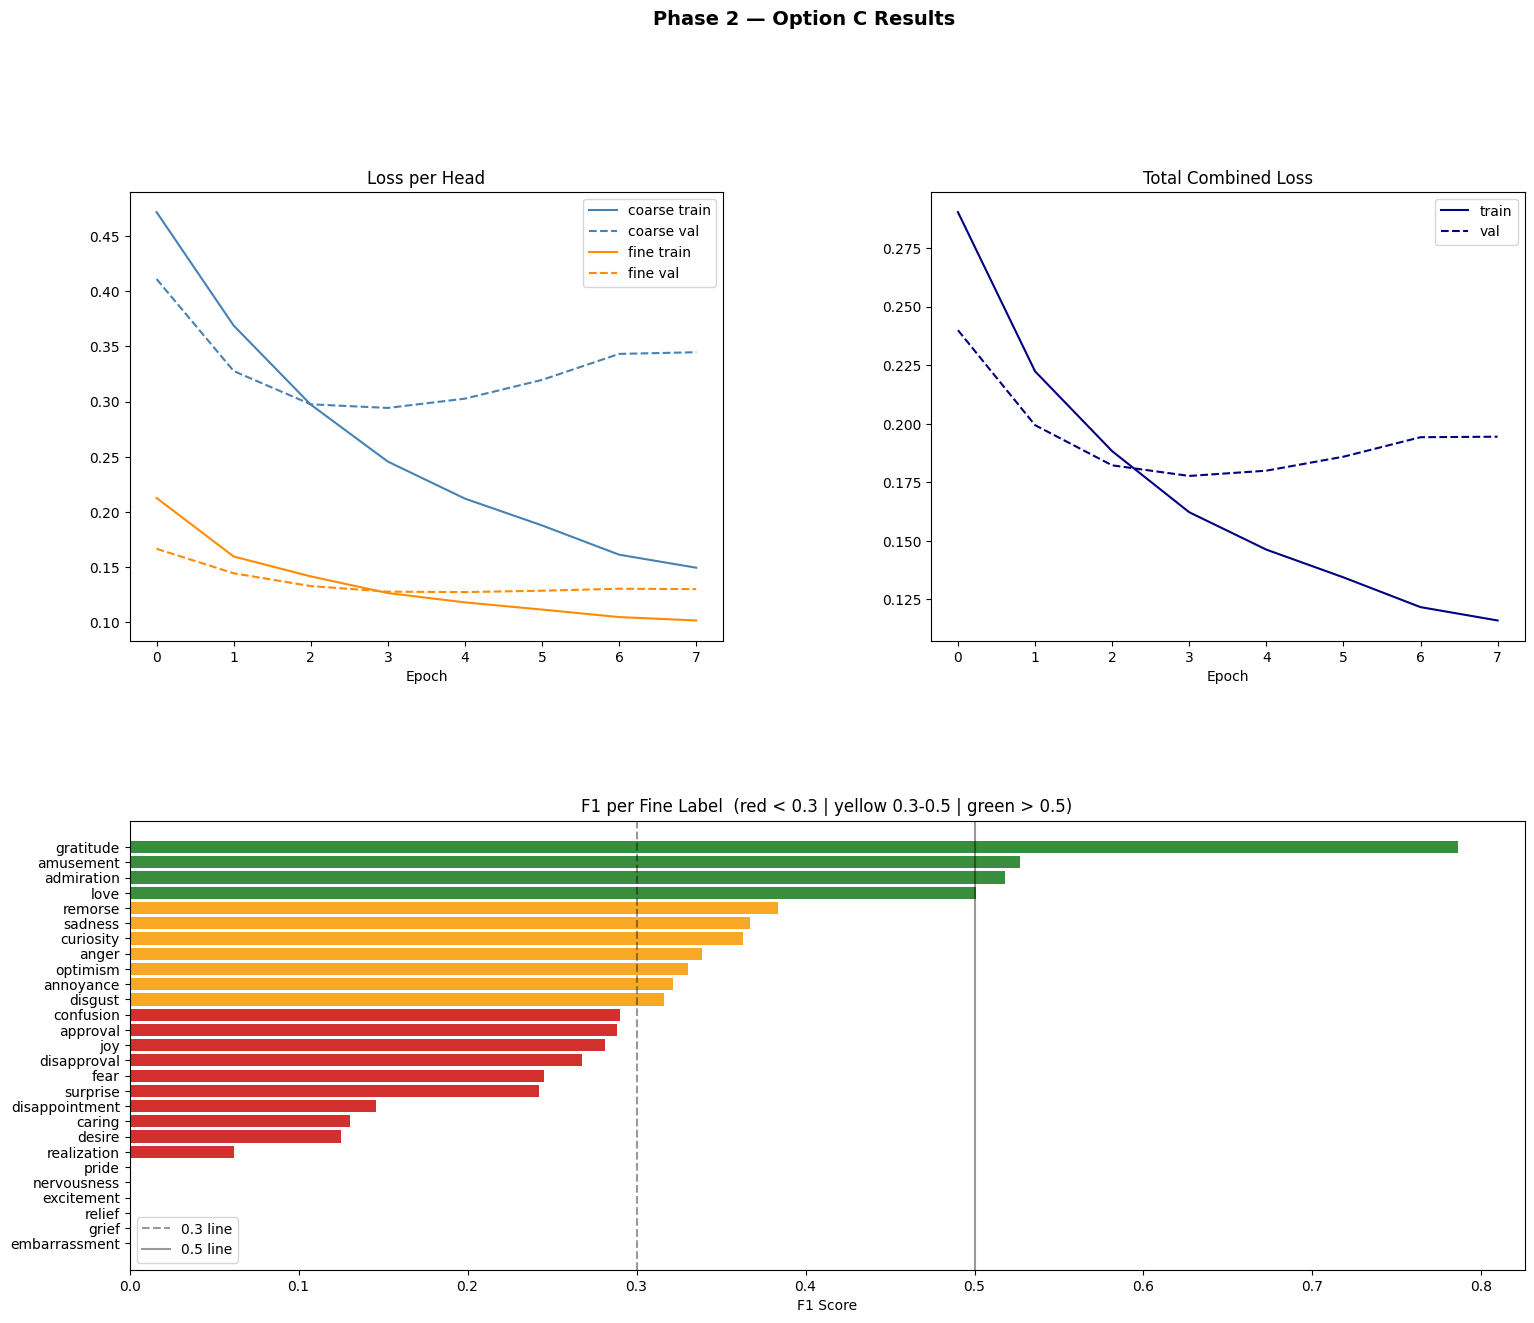

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import f1_score

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Training curves ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['coarse_out_loss'],     label='coarse train', color='steelblue')
ax1.plot(history.history['val_coarse_out_loss'], label='coarse val',   color='steelblue', linestyle='--')
ax1.plot(history.history['fine_out_loss'],       label='fine train',   color='darkorange')
ax1.plot(history.history['val_fine_out_loss'],   label='fine val',     color='darkorange', linestyle='--')
ax1.set_title('Loss per Head'); ax1.legend(); ax1.set_xlabel('Epoch')

# ── 2. Total loss ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['loss'],     label='train', color='navy')
ax2.plot(history.history['val_loss'], label='val',   color='navy', linestyle='--')
ax2.set_title('Total Combined Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

# ── 3. Per-label F1 bar chart ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
f1_per_label = f1_score(y_fine_test, fine_pred, average=None, zero_division=0)
df_f1 = pd.DataFrame({'label': FINE_CLASSES, 'f1': f1_per_label})
df_f1 = df_f1.sort_values('f1', ascending=True)
colors = ['#d32f2f' if f < 0.3 else '#f9a825' if f < 0.5 else '#388e3c'
          for f in df_f1['f1']]
ax3.barh(df_f1['label'], df_f1['f1'], color=colors)
ax3.axvline(0.3, color='black', linestyle='--', alpha=0.4, label='0.3 line')
ax3.axvline(0.5, color='black', linestyle='-',  alpha=0.4, label='0.5 line')
ax3.set_title('F1 per Fine Label  (red < 0.3 | yellow 0.3-0.5 | green > 0.5)')
ax3.set_xlabel('F1 Score'); ax3.legend()

plt.suptitle('Phase 2 — Option C Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase2_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# do some personal test
coarse1, fine1 = model.predict(pad_sequences(tokenizer.texts_to_sequences(["I hope you have a great day!"]), maxlen=MAX_LEN, padding="post", truncating="post"))
coarse1 = (coarse1 >= THRESHOLD).astype(int)
fine1   = (fine1   >= THRESHOLD).astype(int)

coarse2, fine2 = model.predict(pad_sequences(tokenizer.texts_to_sequences(["I am so sad and disappointed."]), maxlen=MAX_LEN, padding="post", truncating="post"))
coarse2 = (coarse2 >= THRESHOLD).astype(int)
fine2   = (fine2   >= THRESHOLD).astype(int)

coarse3, fine3 = model.predict(pad_sequences(tokenizer.texts_to_sequences(["This is the biggest piece of dog shit I have ever seen."]), maxlen=MAX_LEN, padding="post", truncating="post"))
coarse3 = (coarse3 >= THRESHOLD).astype(int)
fine3   = (fine3   >= THRESHOLD).astype(int)

print(f"First, coarse:{coarse1} , fine: {fine1}")
print(f"Second, coarse:{coarse2} , fine: {fine2}")
print(f"Third, coarse:{coarse3} , fine: {fine3}")

# map to correct coarse and fine
def map_to_coarse_fine(coarse, fine):
    coarse_result= []
    fine_result = []
    for i in range(len(coarse)):
        if coarse[i] == 1:
            coarse_result.append(COARSE_CLASSES[i])
    for i in range(len(fine)):
        if fine[i] == 1:
            fine_result.append(FINE_CLASSES[i])
    return coarse_result, fine_result

coarse1 , fine1 = map_to_coarse_fine(coarse1[0], fine1[0])
coarse2 , fine2 = map_to_coarse_fine(coarse2[0], fine2[0])
coarse3 , fine3 = map_to_coarse_fine(coarse3[0], fine3[0])
print(f"First, coarse:{coarse1} , fine: {fine1}")
print(f"Second, coarse:{coarse2} , fine: {fine2}")
print(f"Third, coarse:{coarse3} , fine: {fine3}")


## SUPRISINGLY WE GOT GOOD RESULT, ALL SEEMS CORRECGT !!!!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
First, coarse:[[0 1 0 0 1 0]] , fine: [[0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]]
Second, coarse:[[0 0 1 0 0 0]] , fine: [[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Third, coarse:[[1 0 0 0 0 0]] , fine: [[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
First, coarse:['love', 'joy'] , fine: ['admiration', 'caring', 'joy', 'optimism']
Second, coarse:['sadness'] , fine: ['sadness', 'remorse']
Third, coarse:['anger'] , fine: ['anger', 'annoyance', 'disapproval', 'disgust']
